<a href="https://colab.research.google.com/github/orniTaan/excersice1/blob/main/Assignment_1_Regression_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Assignment 1: Demand prediction of bike sharing system**

Bike sharing services are nowadays spread all over the world. They are beneficial for cities as they offer a climate neutral and healthy way of transportation. Moreover, similar to e-scooters, for the companies and transportation researchers they generate valuable data. This includes the trip route, trip origins and destinations, duration, and much more.

In this assignment we use a public bike sharing dataset from Washington, D.C., USA. published by Fanaee-T, H. (2013). Bike Sharing [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5W894.

## Your Task

Your task in this assignment is:

1) to predict the demand of hourly rentals (**target-column: cnt**) using the [XGBoost](https://xgboost.readthedocs.io/en/stable/) and linear regression model. In this notebook we have provided you with the basic structure how to approach the problem. Feel free to reuse and improve parts of the exercise material.

2) After you have created the model please upload your code to Github and post the link to the notebook in the corresponding forum for the assignment with a short text describing how you have solved the task.

## Load data

You can also find more information about the data and the columns at: https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset

In [1]:
import pandas as pd

url = 'https://raw.githubusercontent.com/zhenliangma/Applied-AI-in-Transportation/master/Exercise_2_regression_model/Exercise2BikeSharing.csv'
df = pd.read_csv(url)

#df = pd.read_csv('Exercise2BikeSharing.csv')
df.head(17379)

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0000,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0000,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0000,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0000,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0000,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17374,17375,2012-12-31,1,1,12,19,0,1,1,2,0.26,0.2576,0.60,0.1642,11,108,119
17375,17376,2012-12-31,1,1,12,20,0,1,1,2,0.26,0.2576,0.60,0.1642,8,81,89
17376,17377,2012-12-31,1,1,12,21,0,1,1,1,0.26,0.2576,0.60,0.1642,7,83,90
17377,17378,2012-12-31,1,1,12,22,0,1,1,1,0.26,0.2727,0.56,0.1343,13,48,61


In [2]:
df.shape

(17379, 17)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


## Train / Test split
- Target: `cnt` (count of total rental bikes including both casual and registered)
- Predictors: weather (`temp`, `atemp`, `hum`, `windspeed`, `weathersit`), calendar (`hr`, `weekday`, `workingday`, `holiday`, `season`), and `yr`.
- We keep it simple; you can expand features (e.g., interactions) later.

In [4]:
from sklearn.model_selection import train_test_split
target = 'cnt'

X = df.copy()
y = df[target].astype(float)

X.drop(columns=[target], inplace=True)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


## Data Processing / Feature Engineering

Before training the model think about data processing and feature engineering steps if applicable, such as:
- adding/removal of features
- normalization
- one hot encoding
- ...


In [ ]:
# Your code here ############################3

In [5]:
# Data Processing / Feature Engineering

# Remove features that cause data leakage or are not useful as predictors

features_to_drop = ['instant', 'dteday', 'casual', 'registered']

X_train_processed = X_train.drop(columns=features_to_drop)
X_test_processed = X_test.drop(columns=features_to_drop)

# Check the remaining features
print(X_train_processed.columns)

Index(['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday',
       'weathersit', 'temp', 'atemp', 'hum', 'windspeed'],
      dtype='object')


In [6]:
from sklearn.preprocessing import StandardScaler

# Create the scaler
scaler = StandardScaler()

# Fit the scaler on training data only
X_train_scaled = scaler.fit_transform(X_train_processed)

# Apply the same transformation to the test data
X_test_scaled = scaler.transform(X_test_processed)

## Hyperparameter optimization
Hyperparameter tuning helps find the best set of hyperparameters for your model. Use Grid Search or Random Search with Cross Validation from scikit-learn to search for the best combination of parameters.

In [ ]:
# Your code here ###########################

In [95]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor

# Create XGBoost model
xgb = XGBRegressor(
    objective='reg:squarederror',
    random_state=42
)

# The Parameters below was found to yield a high R^2 value
param_grid = {
    'n_estimators': [170],
    'max_depth': [8],
    'learning_rate': [0.092]
}

# Grid search with 5-fold cross-validation
grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=5, #10
    scoring='r2',
    n_jobs=-1
)

# Fit grid search
grid_search.fit(X_train_processed, y_train)

# Best parameters
best_params = grid_search.best_params_

print("Best Parameters:", best_params)
print("Best CV R²:", grid_search.best_score_)

Best Parameters: {'learning_rate': 0.092, 'max_depth': 8, 'n_estimators': 170}
Best CV R²: 0.9519306901544761


## Train the XGBoost and Linear regression models
Now, create an XGBoost and linear regression model using the best parameters and train them using the training data.

In [ ]:
# Your code here


In [96]:
## Train the XGBoost and Linear regression models

from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression

# -------------------------
# XGBoost regression model
# -------------------------

xgb_model = XGBRegressor(
    **best_params,
    objective='reg:squarederror',
    random_state=42
)

xgb_model.fit(X_train_processed, y_train)


# -------------------------
# Linear regression model
# -------------------------

lr_model = LinearRegression()

lr_model.fit(X_train_scaled, y_train)

LinearRegression()

## Make predictions
Use the trained models to make predictions on the test data and compare the performance of the XGBoost and linear regression models using metrics like Mean Squared Error (MSE) and R-squared.

In [ ]:
# Your code here

In [97]:
# Make predictions

xgb_pred = xgb_model.predict(X_test_processed)
lr_pred = lr_model.predict(X_test_scaled)

In [98]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# XGBoost
xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_mse = mean_squared_error(y_test, xgb_pred)
xgb_r2 = r2_score(y_test, xgb_pred)

# Linear Regression
lr_mae = mean_absolute_error(y_test, lr_pred)
lr_mse = mean_squared_error(y_test, lr_pred)
lr_r2 = r2_score(y_test, lr_pred)

print("XGBoost")
print("MAE:", xgb_mae)
print("MSE:", xgb_mse)
print("R²:", xgb_r2)

print("\nLinear Regression")
print("MAE:", lr_mae)
print("MSE:", lr_mse)
print("R²:", lr_r2)

XGBoost
MAE: 22.90048733231439
MSE: 1462.2388294277503
R²: 0.9538222063850388

Linear Regression
MAE: 104.80335089554426
MSE: 19379.82836765172
R²: 0.38798115831391333


## Visualize the predictions and compare the mdoels
Create a "Actual vs. Predicted Values" graph to give a visual inspection of the prediction quality.

In [ ]:
# Your Code here

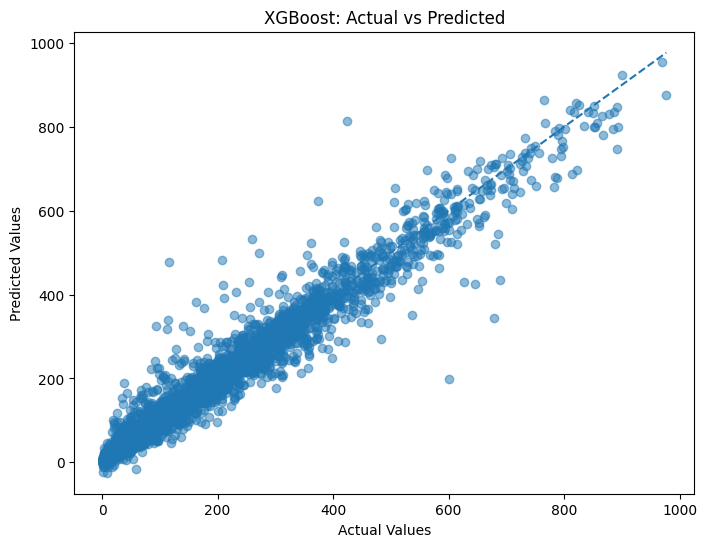

In [99]:
import matplotlib.pyplot as plt

# XGBoost: Actual vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, xgb_pred, alpha=0.5)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("XGBoost: Actual vs Predicted")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)

plt.show()

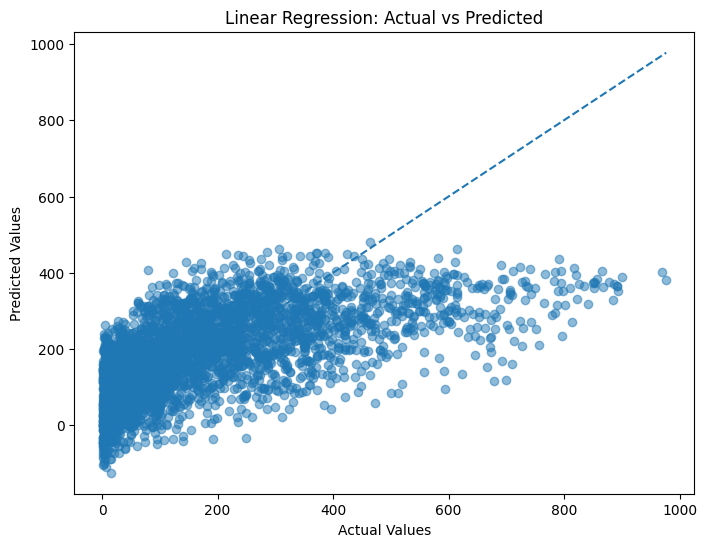

In [100]:
# Linear Regression: Actual vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, lr_pred, alpha=0.5)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Linear Regression: Actual vs Predicted")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)

plt.show()

<Figure size 800x500 with 0 Axes>

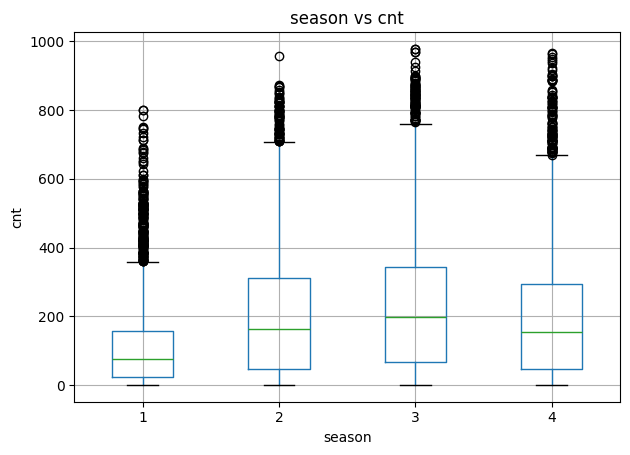

<Figure size 800x500 with 0 Axes>

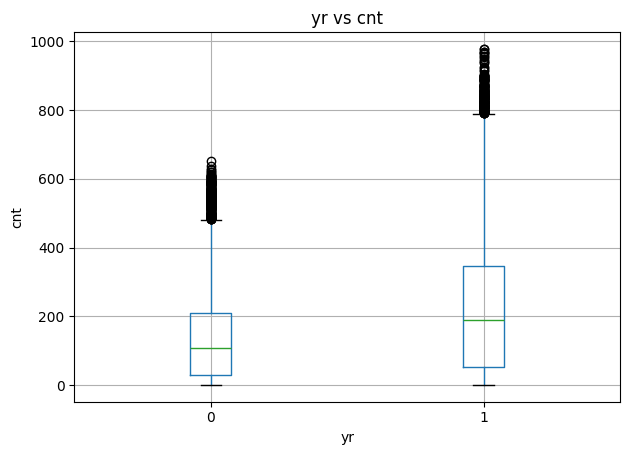

<Figure size 800x500 with 0 Axes>

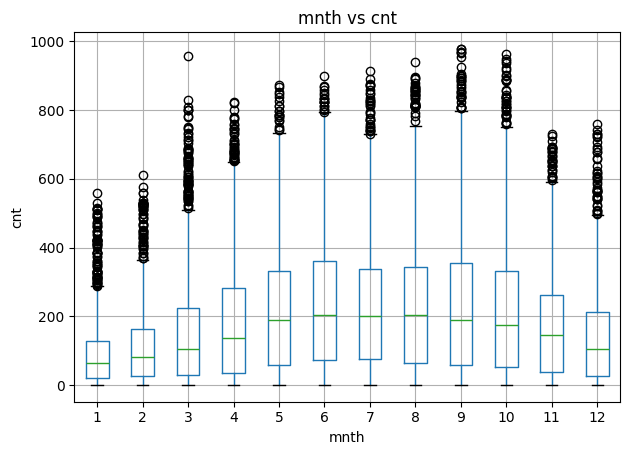

<Figure size 800x500 with 0 Axes>

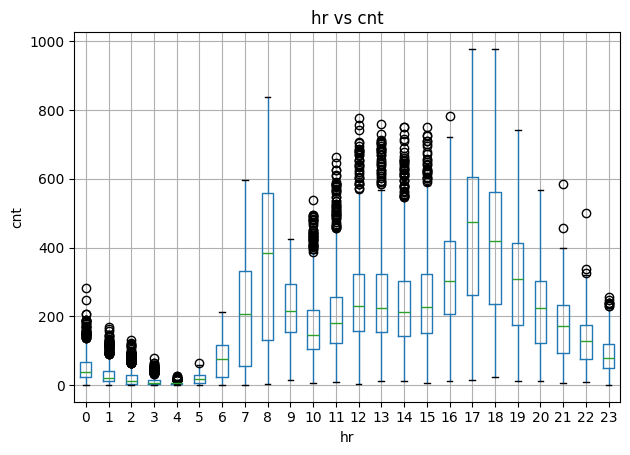

<Figure size 800x500 with 0 Axes>

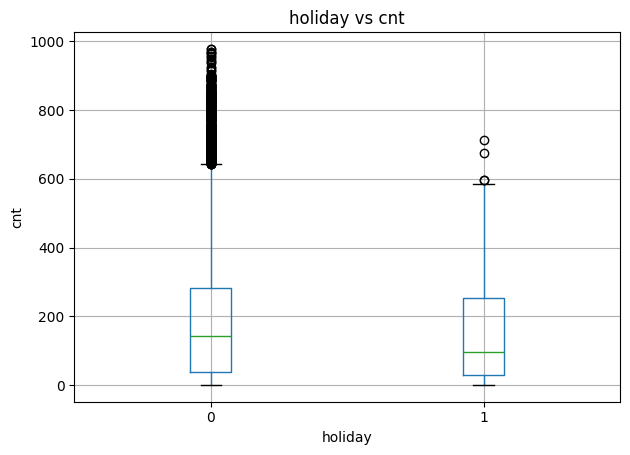

<Figure size 800x500 with 0 Axes>

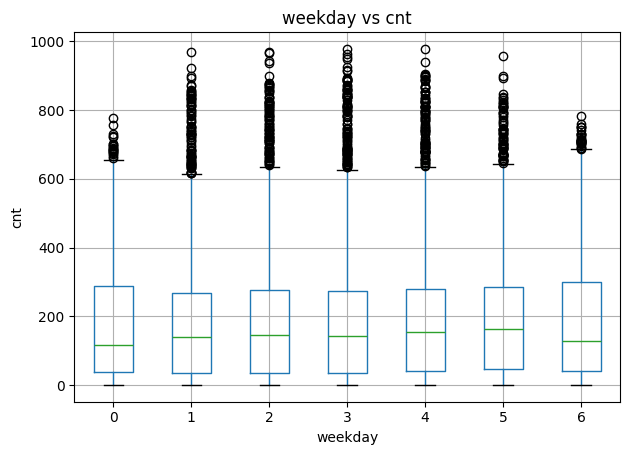

<Figure size 800x500 with 0 Axes>

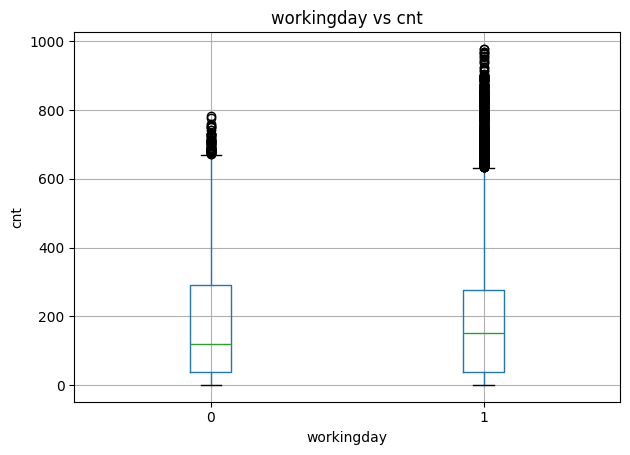

<Figure size 800x500 with 0 Axes>

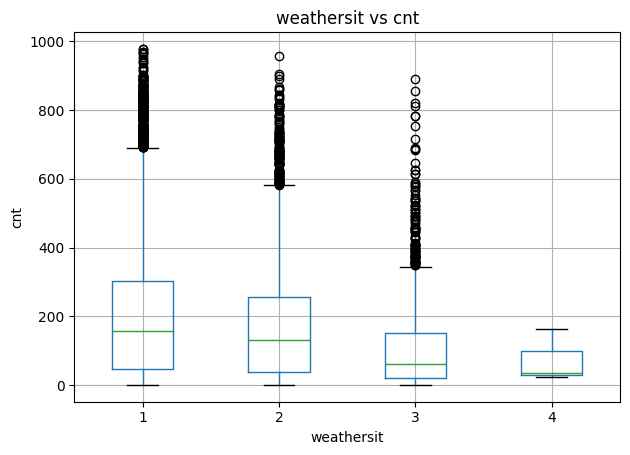

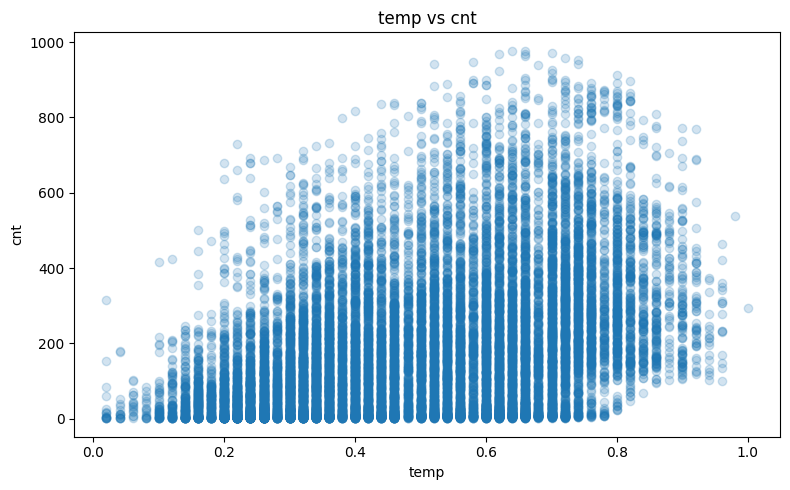

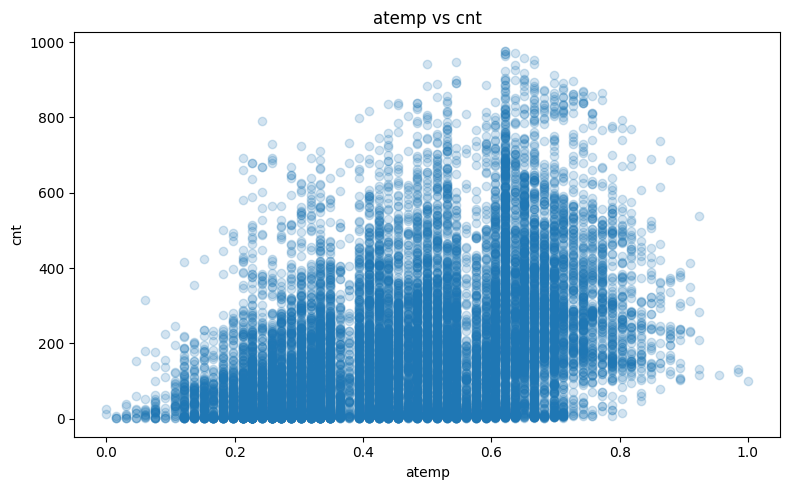

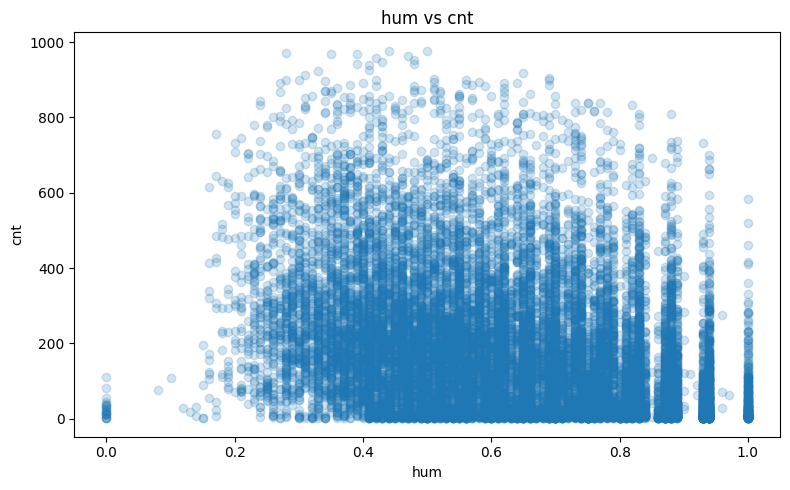

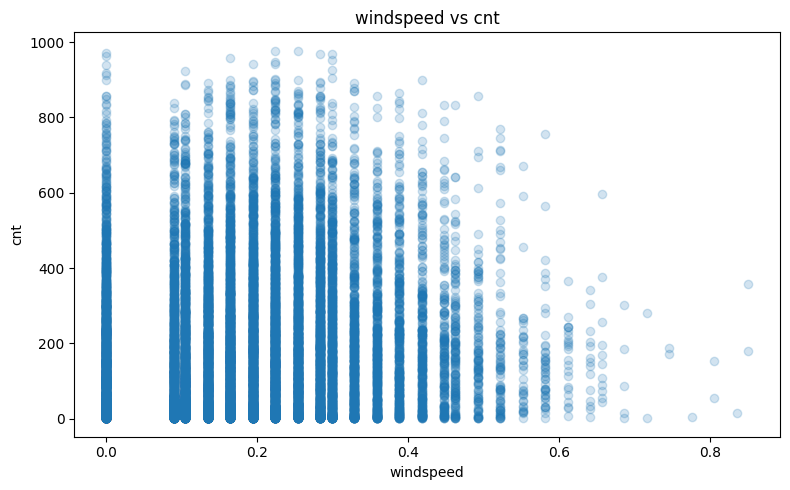

In [68]:
#appendix: How each variable correlates to cnt
import matplotlib.pyplot as plt

# Variables used to predict cnt
features = [
    'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday',
    'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed'
]

# Create a graph for each variable
for feature in features:

    plt.figure(figsize=(8, 5))

    # Continous variables
    if feature in ['temp', 'atemp', 'hum', 'windspeed']:
        plt.scatter(df[feature], df['cnt'], alpha=0.2)

        plt.xlabel(feature)
        plt.ylabel('cnt')
        plt.title(f'{feature} vs cnt')

    # Categorical variables
    else:
        df.boxplot(column='cnt', by=feature)

        plt.xlabel(feature)
        plt.ylabel('cnt')
        plt.title(f'{feature} vs cnt')
        plt.suptitle('')  # removes Pandas standard title

    plt.tight_layout()
    plt.show()